# Poroelasticity Contact Projection Benchmark (`e = 0`)

This notebook is a practical benchmark harness for the three advanced nonsmooth contact projectors in `solve_nivp`:

- `MuScaledSOCProjection`
- `MoreauSOCProjection`
- `AnisotropicSOCProjection`

The benchmark is intentionally split into two families:

1. **A 2D elastic sliding-block FE problem** assembled through the sibling `poroelasticity` package.  This keeps the strong algebraic constraint path from `poroelasticity.build_projection()` in the loop and tests the contact plumbing on a real finite-element system.
2. **Small reduced models** for the cases that a 2D FE block cannot exercise cleanly:
   - `MoreauSOCProjection` is a **velocity-level** projector, so it is benchmarked on a rigid floor-contact model.
   - true anisotropic directionality needs **two tangential directions**, so a 3D reduced slider is added for that.

All cases use **`e = 0` only**.


In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault('OMP_NUM_THREADS', '4')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [start] + list(start.parents):
        if (path / 'solve_nivp').exists() and (path / 'examples').exists():
            return path
    raise RuntimeError('Could not locate repo root containing solve_nivp/ and examples/.')


REPO_ROOT = find_repo_root()
EXAMPLES_DIR = REPO_ROOT / 'examples'
PORO_ROOT = Path('/home/david/Documents/Poroelasticity')

for path in [REPO_ROOT, EXAMPLES_DIR, PORO_ROOT]:
    if path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

import numpy as np
import pandas as pd
import matplotlib

try:
    from IPython import get_ipython
except Exception:
    get_ipython = lambda: None

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')
else:
    matplotlib.use('Agg')

import matplotlib.pyplot as plt

import solve_nivp
from solve_nivp.contact import build_impulse_contact
from solve_nivp.projections import AnisotropicSOCProjection, MoreauSOCProjection
from solve_nivp.nonlinear_solvers import ImplicitEquationSolver
from solve_nivp.integrations import BackwardEuler
from solve_nivp.ODESystem import ODESystem
from solve_nivp.ODESolver import ODESolver

from examples.sliding_block_one_step_patch_test import build_demo_contact_system, audit_state

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)

print(f'repo root: {REPO_ROOT}')
print(f'poro root exists: {PORO_ROOT.exists()}')
print(f'solve_nivp version: {getattr(solve_nivp, "__version__", "dev")}')


repo root: /home/david/Documents/Solve_ivp_ns
poro root exists: True
solve_nivp version: dev


## Parameters

The FE case uses the existing sliding-block helper from `examples/sliding_block_one_step_patch_test.py`.

The anisotropic FE case is still 2D, so it only exercises the **single-tangential-direction** version of the anisotropic projector.  A separate 3D reduced model is included later to test genuine directional anisotropy.


In [2]:
FE_CFG = dict(
    mu_friction=0.35,
    initial_gap_phys=0.0,
    reverse_gap_sign=False,
    top_v1_rate=1.0e-5,
    top_v2_rate=-5.0e-6,
    rho_g=26.5,
    n_elem=4,
    element_type='quad',
)
FE_T_END_HOURS = 0.002
ANISO_2D_EFFECTIVE_MU = 0.15

MOREAU_CFG = dict(
    mu=0.35,
    height=0.10,
    vx0=0.75,
    tf=0.50,
    h0=1.0e-3,
)

ANISO3D_CFG = dict(
    mu_iso=0.35,
    mu_x=0.80,
    mu_y=0.20,
    tf=1.00,
    h0=1.0e-2,
)

print('FE config:')
print(FE_CFG)
print(f'FE_T_END_HOURS = {FE_T_END_HOURS}')
print(f'ANISO_2D_EFFECTIVE_MU = {ANISO_2D_EFFECTIVE_MU}')
print('\nMoreau config:')
print(MOREAU_CFG)
print('\n3D anisotropic config:')
print(ANISO3D_CFG)


FE config:
{'mu_friction': 0.35, 'initial_gap_phys': 0.0, 'reverse_gap_sign': False, 'top_v1_rate': 1e-05, 'top_v2_rate': -5e-06, 'rho_g': 26.5, 'n_elem': 4, 'element_type': 'quad'}
FE_T_END_HOURS = 0.002
ANISO_2D_EFFECTIVE_MU = 0.15

Moreau config:
{'mu': 0.35, 'height': 0.1, 'vx0': 0.75, 'tf': 0.5, 'h0': 0.001}

3D anisotropic config:
{'mu_iso': 0.35, 'mu_x': 0.8, 'mu_y': 0.2, 'tf': 1.0, 'h0': 0.01}


## 1. Finite-Element Elastic Block via `poroelasticity`

This section keeps the **strong algebraic constraint path** from `poroelasticity` in the loop:

- the base FE system is assembled with `CGPoroelastostatics`
- multiplier dynamics are stripped
- `poro.build_projection()` supplies the algebraic constraints
- `build_impulse_contact(...)` adds the nonsmooth contact reaction block

That means the FE benchmark is not just a toy contact law; it is using the same constraint plumbing as the existing sliding-block demo.


In [3]:
def _replace_with_anisotropic_soc(composite_projection, effective_mu_t):
    base_soc = composite_projection.soc_projection
    B_eff = np.array([[1.0 / effective_mu_t**2]], dtype=float)
    new_soc = AnisotropicSOCProjection(
        blocks=base_soc.blocks,
        get_mu=lambda y, _n=len(base_soc.blocks): np.ones(_n),
        gap_func=base_soc.gap_func,
        gap_tol=base_soc.gap_tol,
        zero_inactive=base_soc.zero_inactive,
        get_B=lambda y, k, _B=B_eff: _B,
    )
    new_soc._velocity_dof_map = getattr(base_soc, '_velocity_dof_map', None)
    composite_projection._soc = new_soc
    return B_eff


def make_fe_context(kind='mu_scaled', *, cfg=None, anisotropic_mu=0.15):
    cfg = FE_CFG if cfg is None else dict(cfg)
    if kind == 'anisotropic':
        cfg['mu_friction'] = 1.0
    ctx = build_demo_contact_system(**cfg)
    ctx['backend'] = kind
    if kind == 'anisotropic':
        ctx['anisotropy_B'] = _replace_with_anisotropic_soc(
            ctx['cs'].projection, effective_mu_t=float(anisotropic_mu)
        )
        ctx['effective_mu_t'] = float(anisotropic_mu)
    elif kind == 'mu_scaled':
        ctx['anisotropy_B'] = np.eye(1)
        ctx['effective_mu_t'] = float(cfg['mu_friction'])
    else:
        raise ValueError(f'Unknown FE backend: {kind}')
    return ctx


def fe_constraint_violation(ctx, y):
    alg = ctx['cs'].projection.algebraic_projection
    residual = alg.constraint_residual(y)
    return float(np.max(np.abs(residual)))


def fe_cone_violation(ctx, audit):
    mu_eff = float(ctx['effective_mu_t'])
    viol = np.abs(audit['p_t']) - mu_eff * audit['p_n']
    return float(np.max(viol)), viol


def run_fe_case(kind='mu_scaled', *, cfg=None, t_end_hours=None, anisotropic_mu=0.15):
    ctx = make_fe_context(kind=kind, cfg=cfg, anisotropic_mu=anisotropic_mu)
    t_end_hours = FE_T_END_HOURS if t_end_hours is None else float(t_end_hours)
    tmax = t_end_hours / ctx['poro'].get_scales()[0]

    t_vals, y_vals, h_vals, fk_vals, error_estimates = solve_nivp.solve_nivp(
        fun=ctx['cs'].rhs,
        t_span=(0.0, tmax),
        y0=ctx['cs'].y0,
        method='backward_euler',
        projection=ctx['cs'].projection,
        solver='semismooth_newton',
        projection_opts={},
        solver_opts=ctx['solver_opts_contact'],
        adaptive=False,
        h0=tmax,
        integrator_opts=ctx['cs'].integrator_opts,
        nl_atol=ctx['nl_atol_contact'],
        nl_rtol=1.0e-6,
        component_slices=ctx['cs'].component_slices,
        verbose=False,
        A=ctx['cs'].A,
        store_fk=False,
    )

    solver_error, success, iterations = error_estimates[-1]
    final_y = y_vals[-1]
    audit = audit_state(final_y, ctx)
    cone_max, cone_all = fe_cone_violation(ctx, audit)

    summary = dict(
        backend=kind,
        success=bool(success),
        iterations=int(iterations),
        solver_error=(float(solver_error) if solver_error is not None else np.nan),
        effective_mu_t=float(ctx['effective_mu_t']),
        n_contacts=int(ctx['n_c']),
        gap_min=float(audit['gap_min']),
        gap_max=float(audit['gap_max']),
        max_penetration=float(audit['max_penetration']),
        max_open_reaction=float(audit['max_open_reaction']),
        min_p_N=float(audit['min_pn']),
        max_abs_p_T=float(audit['max_abs_pt']),
        cone_violation=float(cone_max),
        constraint_violation=float(fe_constraint_violation(ctx, final_y)),
    )
    trace = dict(
        contact_index=np.arange(ctx['n_c']),
        gap_phys=np.asarray(audit['gap_phys']),
        p_n=np.asarray(audit['p_n']),
        p_t=np.asarray(audit['p_t']),
        cone_bound=float(ctx['effective_mu_t']) * np.asarray(audit['p_n']),
        t=np.asarray(t_vals),
        y=np.asarray(y_vals),
        cone_violation=np.asarray(cone_all),
    )
    return summary, trace, ctx


In [4]:
fe_results = {}

for backend in ['mu_scaled', 'anisotropic']:
    summary, trace, ctx = run_fe_case(
        kind=backend,
        cfg=FE_CFG,
        t_end_hours=FE_T_END_HOURS,
        anisotropic_mu=ANISO_2D_EFFECTIVE_MU,
    )
    fe_results[backend] = dict(summary=summary, trace=trace, ctx=ctx)

fe_summary = pd.DataFrame([item['summary'] for item in fe_results.values()]).set_index('backend')
fe_summary



Conforming quad mesh: 16 elements, h=0.2500
[RobustCrackGenerator] KDTree facet query: 12 candidates, 12 good (both endpoints within 1.0h, relaxed tips)
[RobustCrackGenerator] Facet hits: 10 | t-range=[0.125, 0.875]
[RobustCrackGenerator] 13 good facets (BOTH endpoints within h), 10 direct hits
[RobustCrackGenerator] Final: 13 good facets (no connectors)
[RobustCrackGenerator] QUAD mesh detected
[RobustCrackGenerator] Axis-aligned crack - using direct column selection
[RobustCrackGenerator] Crack is horizontal
[RobustCrackGenerator] Crack midpoint at [ 0.   -0.25]
[RobustCrackGenerator] Best column: -1 (coord≈-0.2500)
[RobustCrackGenerator] Distance to crack: 0.0000
[RobustCrackGenerator] Facets in column: 4 total, 4 near crack
[RobustCrackGenerator] Selected 4 connected facets
[RobustCrackGenerator] Selected t-range=[0.000, 1.000] | coverage vs good=133.3%
[RobustCrackGenerator] Timing breakdown:
    setup:                     1.6 ms
    find_facets_intersected:   17.1 ms
    find_el

,success,iterations,solver_error,effective_mu_t,n_contacts,gap_min,gap_max,max_penetration,max_open_reaction,min_p_N,max_abs_p_T,cone_violation,constraint_violation
backend,,,,,,,,,,,,,
mu_scaled,True,2,7.191491e-11,0.35,5,-3.817239e-17,-6.938894e-18,3.817239e-17,0.0,6.047387e-08,1.815714e-08,-6.266605e-09,0.0
anisotropic,True,5,1.015398e-05,0.15,5,-3.763750e-05,1.388050e-17,3.763750e-05,0.0,3.529337e-10,1.667282e-08,0.000000e+00,0.0


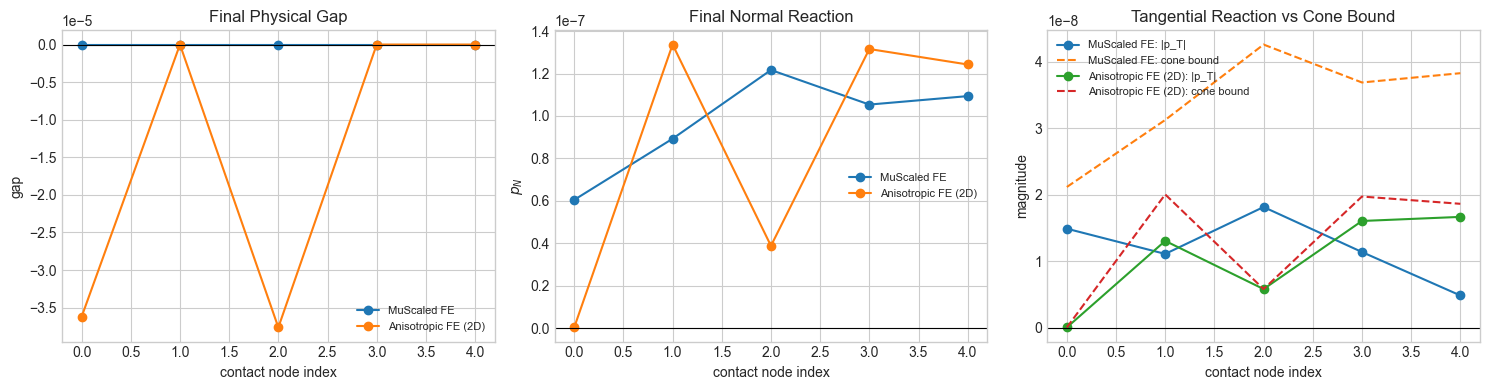

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
labels = {
    'mu_scaled': 'MuScaled FE',
    'anisotropic': 'Anisotropic FE (2D)',
}

for key, item in fe_results.items():
    tr = item['trace']
    x = tr['contact_index']
    axs[0].plot(x, tr['gap_phys'], marker='o', label=labels[key])
    axs[1].plot(x, tr['p_n'], marker='o', label=labels[key])
    axs[2].plot(x, np.abs(tr['p_t']), marker='o', label=f"{labels[key]}: |p_T|")
    axs[2].plot(x, tr['cone_bound'], linestyle='--', label=f"{labels[key]}: cone bound")

axs[0].axhline(0.0, color='k', lw=0.8)
axs[0].set_title('Final Physical Gap')
axs[0].set_xlabel('contact node index')
axs[0].set_ylabel('gap')

axs[1].axhline(0.0, color='k', lw=0.8)
axs[1].set_title('Final Normal Reaction')
axs[1].set_xlabel('contact node index')
axs[1].set_ylabel('$p_N$')

axs[2].axhline(0.0, color='k', lw=0.8)
axs[2].set_title('Tangential Reaction vs Cone Bound')
axs[2].set_xlabel('contact node index')
axs[2].set_ylabel('magnitude')

for ax in axs:
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 2. `MoreauSOCProjection` on a Velocity-Level Floor-Contact Model

`MoreauSOCProjection` is a **velocity-level** projector.  The current poroelasticity helper stack exposes the FE contact problem most cleanly in the **impulse-level** augmented form, so the most honest benchmark for `MoreauSOCProjection` today is a small rigid floor-contact model.

This still matters because it directly tests the path unique to `MoreauSOCProjection`:

- De Saxce augmentation inside the projector
- split tangent (`tangent_cone_split`)
- `e = 0` inelastic impact/contact behaviour


In [6]:
def run_moreau_rigid_case(cfg=None):
    cfg = MOREAU_CFG if cfg is None else dict(cfg)
    mass = 1.0
    A = np.diag([mass, mass, 1.0, 1.0])

    def rhs(t, y):
        return np.array([0.0, -9.81 * mass, y[0], y[1]])

    def gap_func(y, t):
        return np.array([y[3]])

    proj = MoreauSOCProjection(
        blocks=[(1, [0])],
        get_mu=lambda y, _mu=float(cfg['mu']): _mu,
        gap_func=gap_func,
        e=0.0,
    )
    solver = ImplicitEquationSolver(
        method='semismooth_newton',
        proj=proj,
        tol=1.0e-12,
        max_iter=100,
        component_slices=[slice(0, 2), slice(2, 4)],
    )
    integrator = BackwardEuler(solver=solver, A=A)
    y0 = np.array([cfg['vx0'], 0.0, 0.0, cfg['height']], dtype=float)
    system = ODESystem(fun=rhs, y0=y0, method=integrator, adaptive=True)
    driver = ODESolver(system, t_span=(0.0, cfg['tf']), h=cfg['h0'])
    t, y_hist, h_hist, fk_hist, info = driver.solve()

    impulses = np.zeros((len(t) - 1, 2))
    for i in range(len(t) - 1):
        dt_i = t[i + 1] - t[i]
        P = A @ (y_hist[i + 1] - y_hist[i]) - dt_i * rhs(t[i + 1], y_hist[i + 1])
        impulses[i, 0] = P[1]            # normal impulse
        impulses[i, 1] = abs(P[0])       # tangential impulse magnitude

    contact_mask = impulses[:, 0] > 1.0e-10
    cone_viol = impulses[:, 1] - float(cfg['mu']) * impulses[:, 0]
    cone_viol_contact = cone_viol[contact_mask] if np.any(contact_mask) else np.array([0.0])

    summary = dict(
        backend='moreau_rigid',
        mu=float(cfg['mu']),
        n_steps=int(len(t) - 1),
        final_gap=float(y_hist[-1, 3]),
        min_gap=float(np.min(y_hist[:, 3])),
        final_vx=float(y_hist[-1, 0]),
        final_vy=float(y_hist[-1, 1]),
        contact_steps=int(np.count_nonzero(contact_mask)),
        max_cone_violation=float(np.max(cone_viol_contact)),
    )
    trace = dict(
        t=np.asarray(t),
        y=np.asarray(y_hist),
        t_impulse=np.asarray(t[1:]),
        p_n=impulses[:, 0],
        p_t=impulses[:, 1],
        contact_mask=contact_mask,
        mu=float(cfg['mu']),
    )
    return summary, trace


In [7]:
moreau_summary, moreau_trace = run_moreau_rigid_case(MOREAU_CFG)
pd.DataFrame([moreau_summary]).set_index('backend')


,mu,n_steps,final_gap,min_gap,final_vx,final_vy,contact_steps,max_cone_violation
backend,,,,,,,,
moreau_rigid,0.35,63,1.722936e-08,1.722936e-08,0.0,0.0,18,7.135854e-13


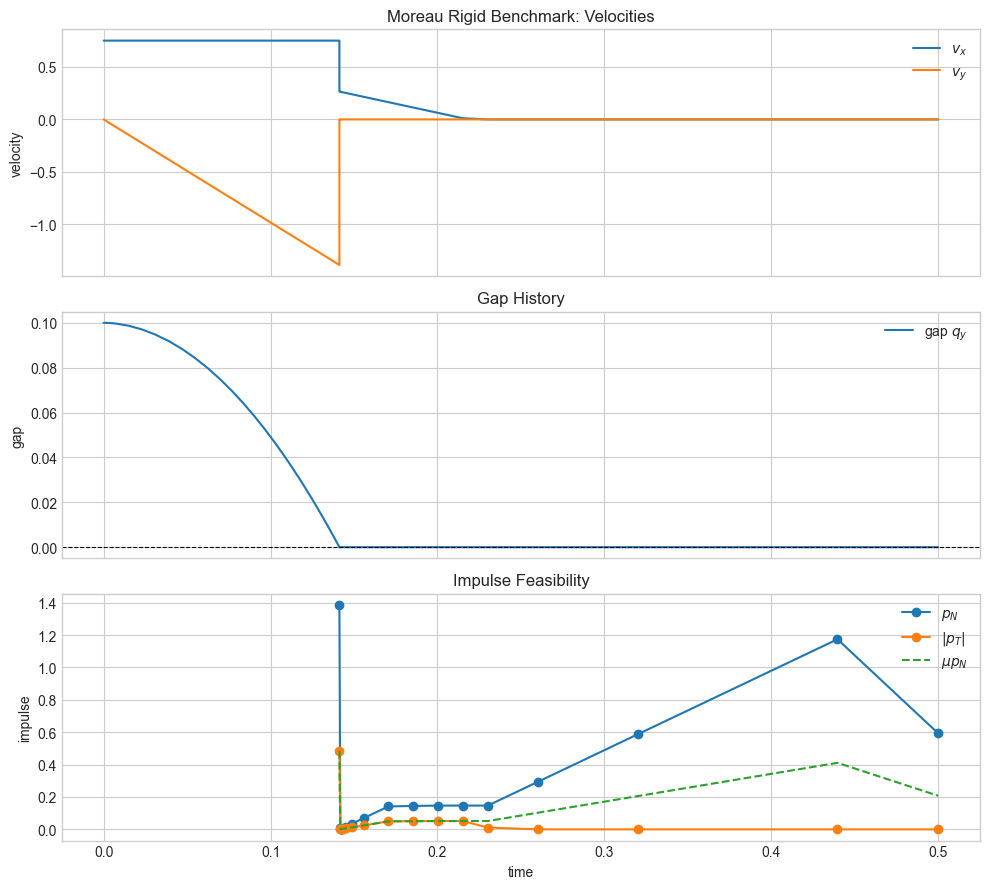

In [8]:
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

t = moreau_trace['t']
y = moreau_trace['y']
mask = moreau_trace['contact_mask']

axs[0].plot(t, y[:, 0], label='$v_x$')
axs[0].plot(t, y[:, 1], label='$v_y$')
axs[0].set_ylabel('velocity')
axs[0].set_title('Moreau Rigid Benchmark: Velocities')
axs[0].legend()

axs[1].plot(t, y[:, 3], label='gap $q_y$')
axs[1].axhline(0.0, color='k', lw=0.8, ls='--')
axs[1].set_ylabel('gap')
axs[1].set_title('Gap History')
axs[1].legend()

if np.any(mask):
    tc = moreau_trace['t_impulse'][mask]
    axs[2].plot(tc, moreau_trace['p_n'][mask], marker='o', label='$p_N$')
    axs[2].plot(tc, moreau_trace['p_t'][mask], marker='o', label='$|p_T|$')
    axs[2].plot(tc, moreau_trace['mu'] * moreau_trace['p_n'][mask], ls='--', label=r'$\mu p_N$')
else:
    axs[2].text(0.5, 0.5, 'No contact impulse detected', ha='center', va='center', transform=axs[2].transAxes)
axs[2].set_ylabel('impulse')
axs[2].set_title('Impulse Feasibility')
axs[2].legend()
axs[2].set_xlabel('time')

plt.tight_layout()
plt.show()


## 3. True Directional Anisotropy in 3D

A 2D FE contact interface has only one tangential direction, so it cannot fully test the geometry of an **elliptic friction cone**.  This reduced 3D slider is included specifically to exercise the real anisotropic case with two tangential directions.


In [9]:
def run_3d_slider_case(kind='isotropic', cfg=None):
    cfg = ANISO3D_CFG if cfg is None else dict(cfg)

    mass = 1.0
    g = 9.81
    k_T = 5.0
    q_eq_x = 1.5
    n_phys = 6
    A = np.diag([mass, mass, mass, 1.0, 1.0, 1.0])
    h_ref = [cfg['h0']]

    def rhs(t, y):
        vx, vy, vz = y[0], y[1], y[2]
        qx = y[3]
        return np.array([
            -k_T * (qx - q_eq_x),
            0.0,
            0.0,
            vx,
            vy,
            vz,
        ])

    gap_func = lambda y, t: np.array([-1.0])
    y0 = np.zeros(n_phys)
    y0[0] = 0.25
    y0[1] = 0.25

    if kind == 'isotropic':
        contacts = [dict(vel_normal_idx=2, vel_tangential_idx=[0, 1], mu=float(cfg['mu_iso']), e=0.0)]
        build_kw = {}
        label = f"isotropic (mu={cfg['mu_iso']:.2f})"
    elif kind == 'anisotropic':
        contacts = [dict(vel_normal_idx=2, vel_tangential_idx=[0, 1], mu=1.0, e=0.0)]
        B = np.diag([1.0 / cfg['mu_x']**2, 1.0 / cfg['mu_y']**2])
        build_kw = {'get_B': lambda y, k, _B=B: _B}
        label = f"anisotropic (mu_x={cfg['mu_x']:.2f}, mu_y={cfg['mu_y']:.2f})"
    else:
        raise ValueError(f'Unknown 3D backend: {kind}')

    cs = build_impulse_contact(
        A=A,
        rhs_smooth=rhs,
        y0=y0,
        contacts=contacts,
        gap_func=gap_func,
        component_slices=[slice(0, 3), slice(3, 6)],
        get_s0=lambda y, _h=h_ref, _m=mass, _g=g: _m * _g * _h[0],
        step_size_ref=h_ref,
        **build_kw,
    )

    t, y, h_hist, fk_hist, info = solve_nivp.solve_nivp(
        fun=cs.rhs,
        t_span=(0.0, cfg['tf']),
        y0=cs.y0,
        A=cs.A,
        method='backward_euler',
        projection=cs.projection,
        solver='semismooth_newton',
        solver_opts=dict(tol=1.0e-12, max_iter=200, lam_update_strategy='none'),
        component_slices=cs.component_slices,
        integrator_opts=cs.integrator_opts,
        adaptive=True,
        h0=cfg['h0'],
    )

    reactions = np.asarray(y[:, 6:9])
    p_n = reactions[:, 0]
    p_t = reactions[:, 1:3]

    if kind == 'isotropic':
        cone_measure = np.linalg.norm(p_t, axis=1) - float(cfg['mu_iso']) * p_n
    else:
        B = np.diag([1.0 / cfg['mu_x']**2, 1.0 / cfg['mu_y']**2])
        cone_measure = np.sqrt(np.einsum('bi,ij,bj->b', p_t, B, p_t)) - p_n

    summary = dict(
        backend=kind,
        label=label,
        n_steps=int(len(t) - 1),
        final_qx=float(y[-1, 3]),
        final_qy=float(y[-1, 4]),
        final_speed_t=float(np.linalg.norm(y[-1, 0:2])),
        max_cone_violation=float(np.max(cone_measure)),
    )
    trace = dict(
        t=np.asarray(t),
        qx=np.asarray(y[:, 3]),
        qy=np.asarray(y[:, 4]),
        vx=np.asarray(y[:, 0]),
        vy=np.asarray(y[:, 1]),
        p_n=p_n,
        p_t=p_t,
    )
    return summary, trace


In [10]:
slider_results = {}
for backend in ['isotropic', 'anisotropic']:
    summary, trace = run_3d_slider_case(backend, ANISO3D_CFG)
    slider_results[backend] = dict(summary=summary, trace=trace)

slider_summary = pd.DataFrame([item['summary'] for item in slider_results.values()]).set_index('backend')
slider_summary


,label,n_steps,final_qx,final_qy,final_speed_t,max_cone_violation
backend,,,,,,
isotropic,isotropic (mu=0.35),59,1.394272,0.057742,1.217610e+00,0.067913
anisotropic,"anisotropic (mu_x=0.80, mu_y=0.20)",93,0.235145,0.014670,5.118669e-16,0.632795


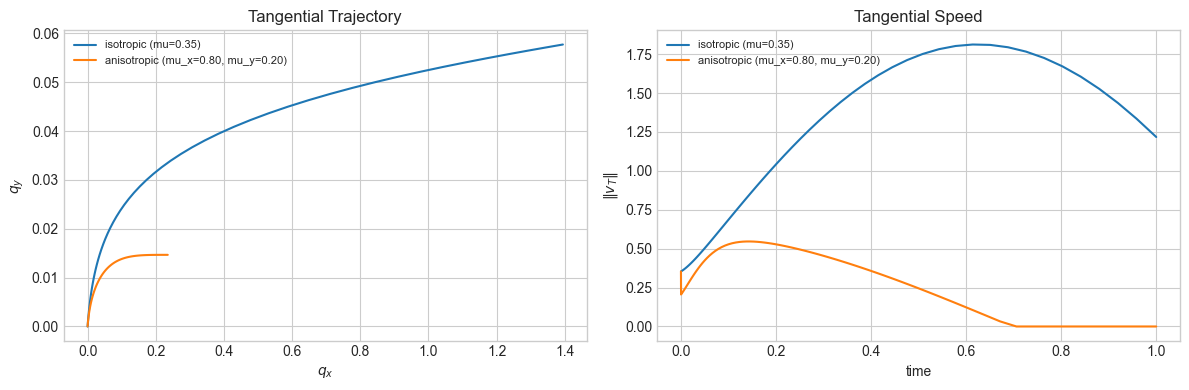

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
labels = {
    'isotropic': slider_results['isotropic']['summary']['label'],
    'anisotropic': slider_results['anisotropic']['summary']['label'],
}

for key, item in slider_results.items():
    tr = item['trace']
    axs[0].plot(tr['qx'], tr['qy'], label=labels[key])
    axs[1].plot(tr['t'], np.sqrt(tr['vx']**2 + tr['vy']**2), label=labels[key])

axs[0].set_title('Tangential Trajectory')
axs[0].set_xlabel('$q_x$')
axs[0].set_ylabel('$q_y$')
axs[0].legend(fontsize=8)

axs[1].set_title('Tangential Speed')
axs[1].set_xlabel('time')
axs[1].set_ylabel(r'$\|v_T\|$')
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Reading the Results

A useful interpretation is:

- **`MuScaledSOCProjection`** is the cleanest full-FE contact path in the current poroelasticity-coupled setup.
- **`MoreauSOCProjection`** is best benchmarked today on a velocity-level model, where its De Saxce machinery is used directly.
- **`AnisotropicSOCProjection`** needs a two-tangential-direction benchmark to show its real advantage, so the 3D reduced slider is the important directional test.

If you later want a **single full-FE benchmark that covers all three in one formulation**, the missing ingredient is a clean velocity-level extracted-contact helper for the poroelasticity assembly so that the Moreau projector can be applied on the mathematically natural variables instead of the impulse-level augmented ones.
